# EV Purchase Prediction：XGBoost V2 主模型优化与集成

## tl;dr

- 旧 `max_bin=4096` 模型使用 1800 棵树，独立留出集 ROC-AUC 为 `0.942993`；延长到最佳约 2160 棵树后提升到 `0.943028`。
- depth 4、depth 6 和 Lossguide 单模型均未超过延长版 depth 5，确认 depth 5 仍是最佳容量。
- 验证驱动的排名融合使用约 62.3% 延长 depth-5、26.7% 低学习率 depth-5、11.0% Lossguide，留出集达到 `0.943040`。
- 全量数据训练了 5 个延长版随机种子，并生成 5-seed 集成、结构排名融合及与 `8192` 模型的公开榜反馈融合。
- 推荐优先提交 `submission_xgb4096_extended_5seed_ensemble.csv`，然后测试结构排名融合与 `80/20` 公开榜融合。

## Context & Methods

### 优化逻辑

公开榜显示 `4096` 双种子集成略优于 `8192` 单模型，说明当前模型更需要降低随机方差，而不是继续提高分箱分辨率。本轮因此同时优化训练轮数、树深度、生长策略和随机种子数量。

### Key Assumptions

- 所有参数候选使用固定训练、调优和独立留出划分。
- 参数与融合权重只根据调优集选择。
- 留出集用于一次最终验收。
- 最终全量训练使用验证得到的最佳轮数，不再进行测试集导向调参。

## Data

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve().parent
ARTIFACT_DIR = ROOT / "artifacts"
SUBMISSION_DIR = ROOT / "submissions"
TARGET = "Will_Buy_EV"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.titleweight"] = "bold"

results = pd.read_csv(ARTIFACT_DIR / "main_xgboost_v2_results.csv")
with open(ARTIFACT_DIR / "main_xgboost_v2_summary.json", encoding="utf-8") as file:
    summary = json.load(file)
training_summary = pd.read_csv(ARTIFACT_DIR / "xgboost_v2_training_summary.csv")

results

,Model,Best_Iteration,Fit_Seconds,Tuning_ROC_AUC,Tuning_Log_Loss,Tuning_Average_Precision,Holdout_ROC_AUC,Holdout_Log_Loss,Holdout_Average_Precision
0,Rank_Forward_Ensemble,NaN,NaN,0.943009,NaN,0.763474,0.943040,NaN,0.764482
1,Depth5_Baseline,2159.0,82.694036,0.942994,0.224369,0.763402,0.943028,0.224185,0.764550
2,Depth5_Long_LowLR,2986.0,104.846690,0.942970,0.224410,0.763162,0.943003,0.224258,0.763990
3,Depth4_Long,3199.0,128.441406,0.942876,0.224616,0.762847,0.942910,0.224441,0.763799
4,Lossguide_31,2313.0,99.173740,0.942877,0.224539,0.763283,0.942891,0.224484,0.763622
5,Depth6_Regularized,2172.0,99.387807,0.942780,0.224744,0.762702,0.942839,0.224546,0.763392


## Results

### 1. 主模型结构比较

In [2]:
results[[
    "Model",
    "Best_Iteration",
    "Fit_Seconds",
    "Tuning_ROC_AUC",
    "Holdout_ROC_AUC",
    "Holdout_Log_Loss",
]].sort_values("Holdout_ROC_AUC", ascending=False)

,Model,Best_Iteration,Fit_Seconds,Tuning_ROC_AUC,Holdout_ROC_AUC,Holdout_Log_Loss
0,Rank_Forward_Ensemble,NaN,NaN,0.943009,0.943040,NaN
1,Depth5_Baseline,2159.0,82.694036,0.942994,0.943028,0.224185
2,Depth5_Long_LowLR,2986.0,104.846690,0.942970,0.943003,0.224258
3,Depth4_Long,3199.0,128.441406,0.942876,0.942910,0.224441
4,Lossguide_31,2313.0,99.173740,0.942877,0.942891,0.224484
5,Depth6_Regularized,2172.0,99.387807,0.942780,0.942839,0.224546


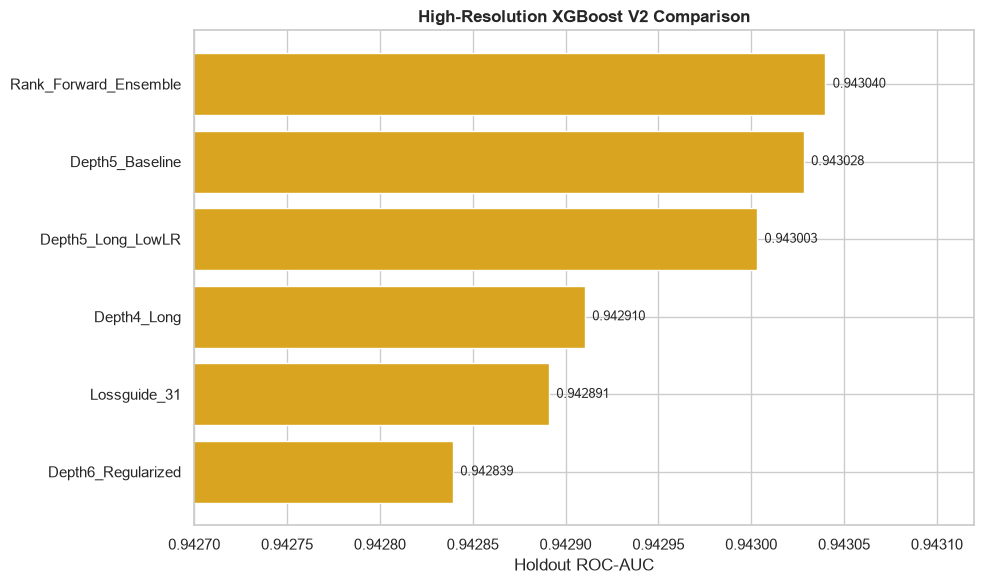

In [3]:
ordered = results.sort_values("Holdout_ROC_AUC")
fig, axis = plt.subplots(figsize=(10, 6))
axis.barh(ordered["Model"], ordered["Holdout_ROC_AUC"], color="#D9A520")
axis.set_xlim(0.9427, 0.94312)
axis.set_xlabel("Holdout ROC-AUC")
axis.set_title("High-Resolution XGBoost V2 Comparison")
for index, value in enumerate(ordered["Holdout_ROC_AUC"]):
    axis.text(value + 0.000004, index, f"{value:.6f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

直接延长 depth-5 模型带来稳定增益。更低学习率版本非常接近，但没有单独超过主模型；depth 4 容量略低，depth 6 则更容易学习噪声。Lossguide 提供少量不同排序，因此被保留用于小权重结构融合。

### 2. 验证学习的结构融合权重

In [4]:
weight_table = pd.DataFrame({
    "Model": list(summary["ensemble_weights"].keys()),
    "Weight": list(summary["ensemble_weights"].values()),
}).sort_values("Weight", ascending=False)
weight_table

,Model,Weight
0,Depth5_Baseline,0.623
1,Depth5_Long_LowLR,0.267
4,Lossguide_31,0.110
2,Depth4_Long,0.000
3,Depth6_Regularized,0.000


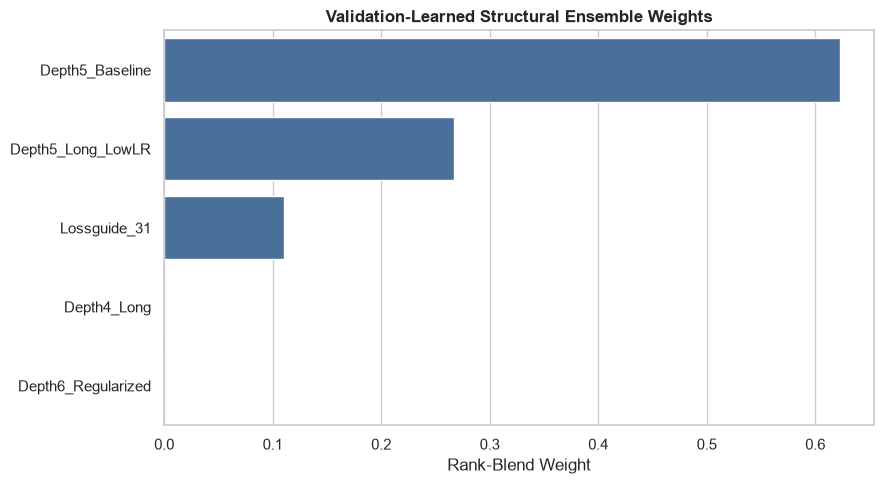

In [5]:
fig, axis = plt.subplots(figsize=(9, 5))
sns.barplot(data=weight_table, y="Model", x="Weight", color="#3B6EA8", ax=axis)
axis.set_title("Validation-Learned Structural Ensemble Weights")
axis.set_xlabel("Rank-Blend Weight")
axis.set_ylabel("")
plt.tight_layout()
plt.show()

融合只保留三种质量接近的模型。与此前 RF、SVM、CatBoost 和 LightGBM 权重被压到零不同，这三个 XGBoost 结构在保持高精度的同时提供了可利用的细微排序差异。

### 3. 全量训练成本

In [6]:
training_summary.groupby("Model", as_index=False).agg(
    Models=("Seed", "count"),
    Mean_Fit_Seconds=("Fit_Seconds", "mean"),
    Total_Fit_Seconds=("Fit_Seconds", "sum"),
)

,Model,Models,Mean_Fit_Seconds,Total_Fit_Seconds
0,Depth5_Extended,5,66.408945,332.044725
1,Depth5_Long_LowLR,1,89.070025,89.070025
2,Lossguide_31,1,83.507108,83.507108


### 4. 新提交文件相关性

In [7]:
submission_files = {
    "Previous_4096_2Seed": "submission_xgboost_finebin_4096_seed_ensemble.csv",
    "Previous_8192": "submission_xgboost_finebin_8192_seed_42.csv",
    "Extended_4096_5Seed": "submission_xgb4096_extended_5seed_ensemble.csv",
    "V2_Structural_Rank": "submission_xgb_v2_structural_rank_ensemble.csv",
    "V2_Public_80_20": "submission_xgb_v2_public_blend_80_20.csv",
}
submission_predictions = pd.DataFrame({
    name: pd.read_csv(SUBMISSION_DIR / filename)[TARGET]
    for name, filename in submission_files.items()
})
submission_predictions.agg(["mean", "std", "min", "max"]).T

,mean,std,min,max
Previous_4096_2Seed,0.174700,0.270457,0.000009,0.999394
Previous_8192,0.174711,0.270512,0.000009,0.999339
Extended_4096_5Seed,0.174683,0.270724,0.000007,0.999558
V2_Structural_Rank,0.500002,0.288635,0.000006,1.000000
V2_Public_80_20,0.174689,0.270669,0.000007,0.999514


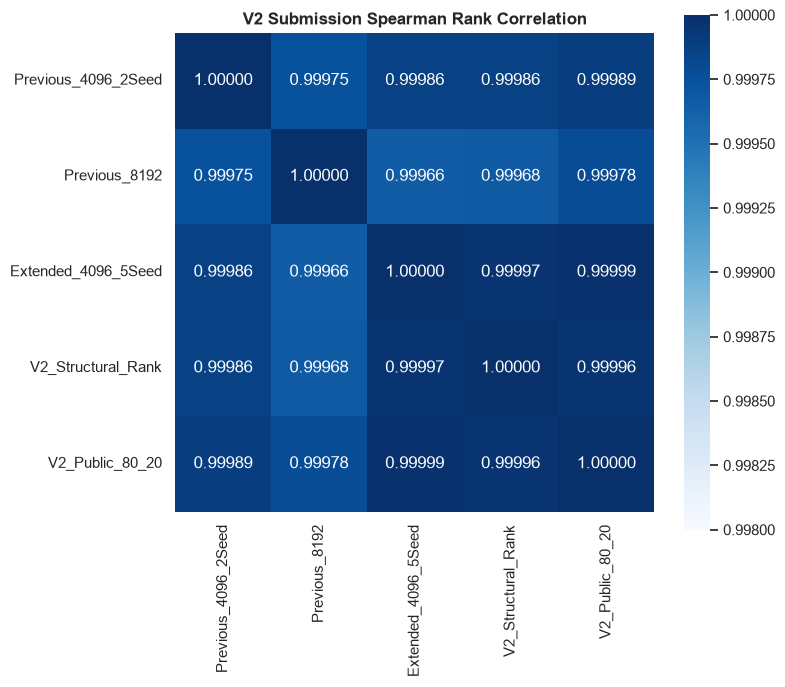

In [8]:
correlation = submission_predictions.corr(method="spearman")
fig, axis = plt.subplots(figsize=(8, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".5f",
    cmap="Blues",
    vmin=0.998,
    vmax=1.0,
    square=True,
    ax=axis,
)
axis.set_title("V2 Submission Spearman Rank Correlation")
plt.tight_layout()
plt.show()

新旧预测高度相关，因此预期提升仍然是排行榜末位小数级别。5-seed 文件主要降低随机方差；结构排名融合利用不同生长方式；`80/20` 文件则结合公开榜表现较好的 `4096` 与连续分辨率更高的 `8192`。

## Takeaways

### 推荐提交顺序

1. `submission_xgb4096_extended_5seed_ensemble.csv`
2. `submission_xgb_v2_structural_rank_ensemble.csv`
3. `submission_xgb_v2_public_blend_80_20.csv`

### 结论

- 延长训练轮数是本轮最可靠的单模型增益。
- 5-seed 集成是针对公开榜反馈最合理的降方差升级。
- 只有与主模型精度非常接近的结构变体才有融合价值。
- RF、SVM、Extra Trees、LightGBM GOSS 和 CatBoost Lossguide 的验证结果均不支持进入最终集成。

### Reproducible artifacts

- `optimize_main_xgboost_v2.py`
- `train_xgboost_v2_ensemble.py`
- `artifacts/main_xgboost_v2_results.csv`
- `artifacts/main_xgboost_v2_summary.json`